In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
collisions = pd.read_csv("collisions.csv")

In [3]:
col_long = pd.wide_to_long(collisions.filter(regex="pid|cond|world|response|baseImg"),
                           ["cond", "response", "baseImg", "world"], i="pid", j="trial")

In [4]:
col_long = col_long.assign(root = col_long.baseImg.str.extract("(.*base)"))

In [5]:
col_long.groupby("cond")["response"].describe()

,count,mean,std,min,25%,50%,75%,max
cond,,,,,,,,
col_early_translate,200.0,97.295,9.476126,20.0,100.0,100.0,100.00,100.0
col_late_translate,200.0,80.000,23.187243,0.0,71.0,86.0,100.00,100.0
maybecol_translate,200.0,51.220,34.942042,0.0,16.5,58.5,80.00,100.0
nocol_translate,200.0,10.625,20.159275,0.0,0.0,0.0,12.25,100.0


[Text(0, 0, 'nocol_translate'),
 Text(0, 0, 'maybecol_translate'),
 Text(0, 0, 'col_late_translate'),
 Text(0, 0, 'col_early_translate')]

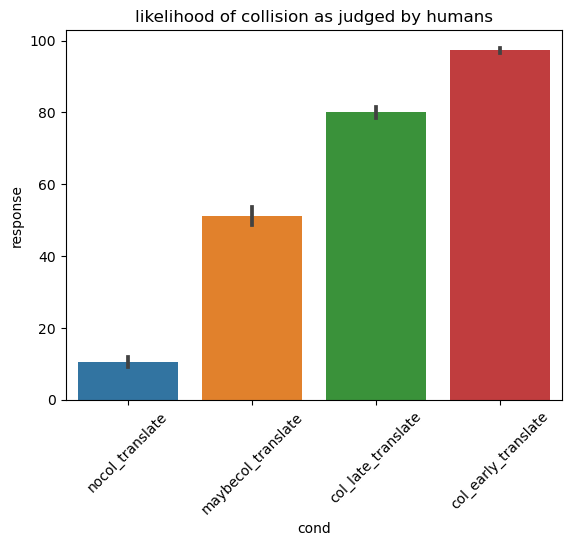

In [6]:
p = sns.barplot(col_long, x="cond", y="response", errorbar="se",
           order=col_long.groupby("cond")["response"].mean().sort_values().reset_index().cond)
p.set(
    title="likelihood of collision as judged by humans"
)
p.set_xticklabels(p.get_xticklabels(), rotation=45)

In [7]:
def likelihood_hist(df, cond):
    out = df.loc[df.cond == cond]
    out = out.groupby("root")["response"].mean().reset_index()
    return sns.histplot(out, x="response")

[(0.0, 100.0)]

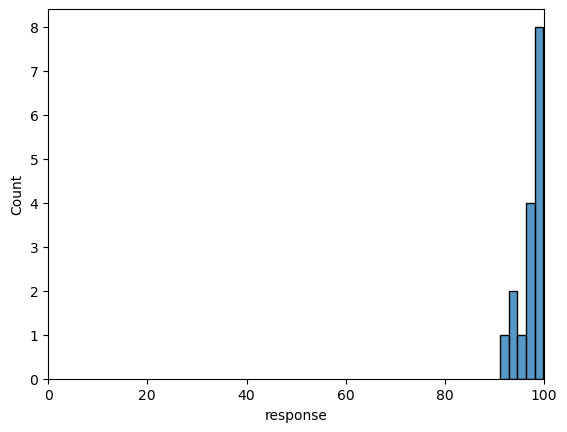

In [8]:
likelihood_hist(col_long, "col_early_translate").set(xlim=(0, 100))

[(0.0, 100.0)]

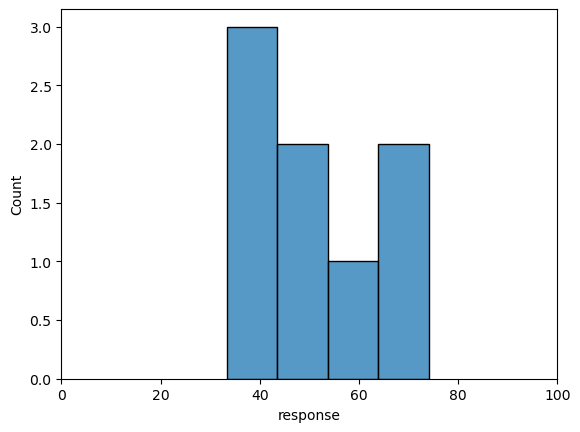

In [9]:
likelihood_hist(col_long, "maybecol_translate").set(xlim=(0, 100))

[(0.0, 100.0)]

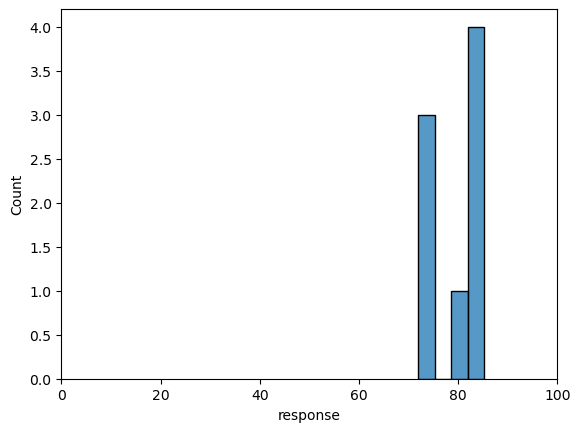

In [10]:
likelihood_hist(col_long, "col_late_translate").set(xlim=(0, 100))

[(0.0, 100.0)]

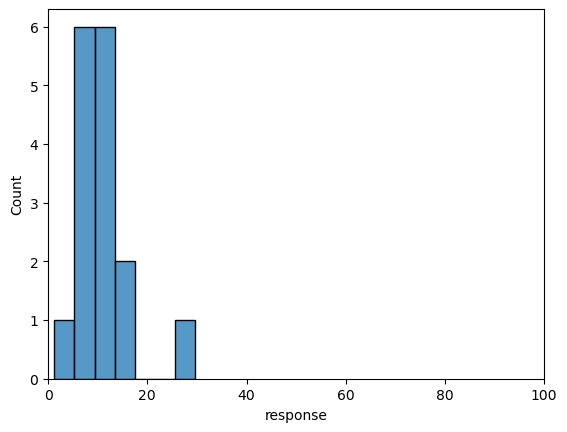

In [11]:
likelihood_hist(col_long, "nocol_translate").set(xlim=(0, 100))

In [12]:
def tmp(df):
    df = df.copy()
    person = df.groupby("pid")["response"].agg(["mean", "std"]).reset_index()
    df = pd.merge(df, person, on="pid")
    df = df.assign(response_z = ((df["response"] - df["mean"]) / df["std"]))
    return df
col_long_z = tmp(col_long)

In [13]:
col_long_z

,pid,cond,response,baseImg,world,root,mean,std,response_z
0,5f4ab4bbf5991167732b47c0,nocol_translate,13,assets/targets/hh_hl_unlink_plinko_0269/nocol_...,hh_hl_unlink_plinko_0269,assets/targets/hh_hl_unlink_plinko_0269/nocol_...,64.9375,21.302484,-2.438096
1,5f4ab4bbf5991167732b47c0,maybecol_translate,79,assets/targets/hh_hl_unlink_plinko_0393/maybec...,hh_hl_unlink_plinko_0393,assets/targets/hh_hl_unlink_plinko_0393/maybec...,64.9375,21.302484,0.660134
2,5f4ab4bbf5991167732b47c0,col_early_translate,89,assets/targets/hh_hl_unlink_plinko_0105/col_ea...,hh_hl_unlink_plinko_0105,assets/targets/hh_hl_unlink_plinko_0105/col_ea...,64.9375,21.302484,1.129563
3,5f4ab4bbf5991167732b47c0,nocol_translate,29,assets/targets/lh_hl_unlink_plinko_0036/nocol_...,lh_hl_unlink_plinko_0036,assets/targets/lh_hl_unlink_plinko_0036/nocol_...,64.9375,21.302484,-1.687010
4,5f4ab4bbf5991167732b47c0,maybecol_translate,69,assets/targets/hh_hl_unlink_plinko_0246/maybec...,hh_hl_unlink_plinko_0246,assets/targets/hh_hl_unlink_plinko_0246/maybec...,64.9375,21.302484,0.190705
...,...,...,...,...,...,...,...,...,...
795,5c510b41e459660001e38861,col_late_translate,70,assets/targets/lh_hl_unlink_plinko_0036/col_la...,lh_hl_unlink_plinko_0036,assets/targets/lh_hl_unlink_plinko_0036/col_la...,60.5625,23.709263,0.398051
796,5c510b41e459660001e38861,maybecol_translate,83,assets/targets/hh_hl_unlink_plinko_0246/maybec...,hh_hl_unlink_plinko_0246,assets/targets/hh_hl_unlink_plinko_0246/maybec...,60.5625,23.709263,0.946360
797,5c510b41e459660001e38861,col_early_translate,83,assets/targets/hh_hl_unlink_plinko_0240/col_ea...,hh_hl_unlink_plinko_0240,assets/targets/hh_hl_unlink_plinko_0240/col_ea...,60.5625,23.709263,0.946360
798,5c510b41e459660001e38861,col_early_translate,71,assets/targets/lh_ll_unlink_plinko_0060/col_ea...,lh_ll_unlink_plinko_0060,assets/targets/lh_ll_unlink_plinko_0060/col_ea...,60.5625,23.709263,0.440229


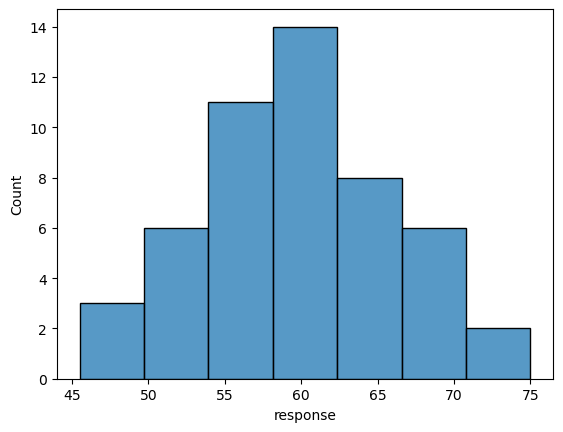

In [14]:
sns.histplot(col_long.groupby("pid")["response"].mean())

In [15]:
person = col_long.groupby("pid")["response"].agg(["mean", "std"])
tmp = pd.merge(col_long, person, on="pid")
tmp = tmp.assign(response_z = ((tmp["response"] - tmp["mean"]) / tmp["std"]))
tmp.groupby("pid")["response_z"].mean()

pid
55cf91b434e9060012e56fba    1.387779e-17
57fb972266e0d000010f7ef2    1.387779e-17
599f7acaec626e0001d53f8f    8.326673e-17
5a8b61fcf1408d000176b02f    0.000000e+00
5a9416ba6475f900019fa690    1.040834e-17
5aaf13dbfb22320001bab178   -2.775558e-17
5b1690e6f6cef00001428471   -3.469447e-17
5b48f2d0ff7497000125165e    6.245005e-17
5bad6504f588f200012bab65   -5.551115e-17
5bee18e1824eae0001669764    0.000000e+00
5c3517a567013e0001eff811    2.775558e-17
5c4b844bd8496e0001ede2bf   -6.938894e-18
5c510b41e459660001e38861    4.857226e-17
5c68af707d17f800013f6ad9   -1.301043e-17
5c8f224c9d2bff0001867ce2    6.938894e-18
5d305152b2cfe00019231a2a   -1.387779e-17
5d3356323e1190001909339b   -1.691355e-17
5dd06ed53c870a1526a78264    2.428613e-17
5df95a0e9a993f6ddf0fdc2c    2.775558e-17
5e30e028dea8d60e2ab7abd6   -8.673617e-18
5e567cd58e4500024e8d096c    5.551115e-17
5ea9ee70bd6e6c158af94cca   -8.326673e-17
5ebedc3f1255ce0db7a5123d    0.000000e+00
5f4ab4bbf5991167732b47c0   -6.938894e-18
5facc4201f33

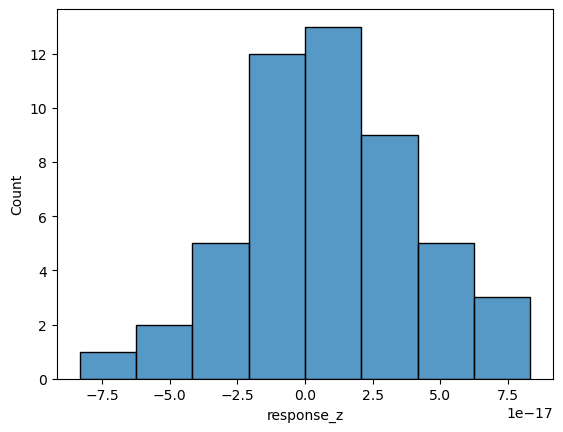

In [16]:
sns.histplot(col_long_z.groupby("pid")["response_z"].mean())

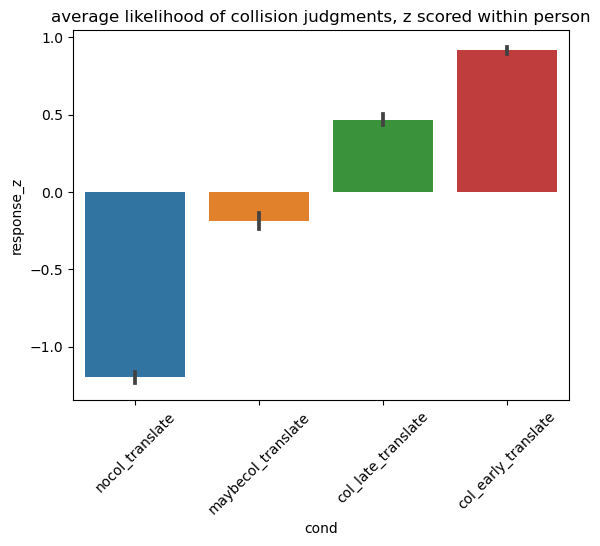

In [17]:
p = sns.barplot(col_long_z, x="cond", y="response_z", errorbar="se",
           order=col_long_z.groupby("cond")["response_z"].mean().sort_values().reset_index().cond)
p.set_title("average likelihood of collision judgments, z scored within person")
for item in p.get_xticklabels():
    item.set_rotation(45)

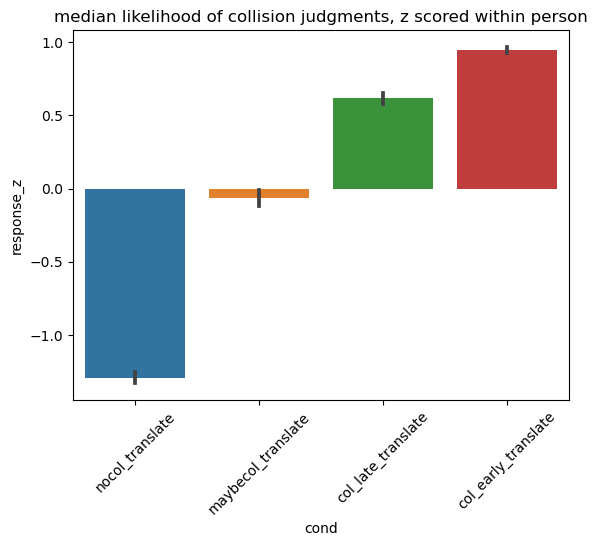

In [18]:
p = sns.barplot(col_long_z, x="cond", y="response_z", errorbar="se",
                estimator=np.median,
           order=col_long_z.groupby("cond")["response_z"].mean().sort_values().reset_index().cond)
p.set_title("median likelihood of collision judgments, z scored within person")
for item in p.get_xticklabels():
    item.set_rotation(45)

In [19]:
def tmp():
    # out = col_long_z.groupby("baseImg")["response_z"].mean().reset_index()
    col_long_z.to_csv("collision_judgments_cleaned.csv", index=False)
tmp()